# Idealized Case 1: Tracking of a Test Blob in 2D 

This tutorial shows the most important steps of tracking with `tobac` using an idealized case:

1. [Input Data](#1.-Input-Data)
2. [Feature Detection](#2.-Feature-Detection)
3. [Tracking / Trajectory Linking](#3.-Trajectory-Linking)
4. [Segmentation](#4.-Segmentation)
5. [Statistical Analysis](#5.-Statistical-Analysis)

## Import Libraries

We start by importing tobac:

In [315]:
import tobac
import imageio
import os
print('using tobac version', str(tobac.__version__))

# we add testing here to create test dataset (typically not needed in standard applications)
import tobac.testing

using tobac version 1.6.1


We will also need matplotlib in inline-mode for plotting and numpy:

In [316]:
import matplotlib.pyplot as plt

import numpy as np

For a better readability of the graphs:

In [317]:
import seaborn as sns

sns.set_context("talk")

Tobac works with a Python package called `xarray`, which introduces `DataArrays`. In a nutshell these are `numpy`-arrays with labels. For a more extensive description have a look at the [xarray Documentation](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.html#xarray.DataArray).

## 1. Input Data

    
There are several utilities implemented in tobac to create simple examples of such arrays. In this tutorial we will use the function `make_simple_sample_data_2D()` to create a moving test blob in 2D:

In [318]:
folder = "./to_test_real_1/resized/"
image_files = ([os.path.join(folder, f) for f in os.listdir(folder)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))])

As you can see our generated data describes a field called 'w' with the unit m/s at 100, 50 and 100 datapoints of time, x and y. Additionally, the data contains the latitude and longitude coordinates of the field values. To access the values of 'w' in the first timeframe, we can use

which is then just an array of numbers of the described shape.

To visualize the data, we can plot individual time frames using matplotlib per imshow:

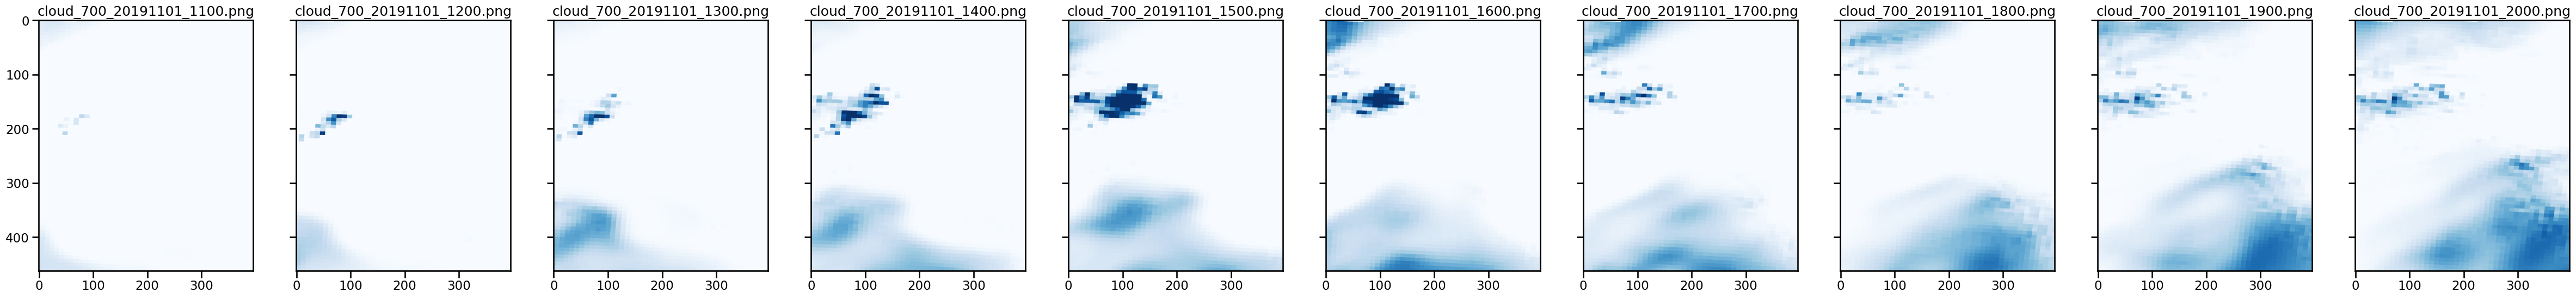

In [319]:
import re

def extract_keys(filename):
    # match pattern like cloud_200_YYYYMMDD_HHMM.png
    m = re.search(r'_(\d{8})_(\d+)\.png$', filename)
    if m:
        date = int(m.group(1))
        num = int(m.group(2))
        return (date, num)
    else:
        return (0, 0)

image_files = sorted(image_files, key=extract_keys)


fig, axs = plt.subplots(ncols=10, nrows=1, figsize=(6*10, 6), sharey=True)
plt.subplots_adjust(hspace=20)
frames = [imageio.v2.imread(f) for f in image_files]
for i, itime in enumerate(range(0,10)):
    img = imageio.v2.imread(image_files[itime])
    axs[i].imshow(img)
    axs[i].set_title(os.path.basename(image_files[itime]))


plt.show()

In [320]:
#generate datatimes from images

import pandas as pd
datetimes = []
for f in image_files:
    basename = os.path.basename(f)
    # Example: "cloud_123_20251008_1200.png"
    # Split by underscore and take the last two parts
    parts = basename.split("_")
    date_str = parts[-2]      # YYYYMMDD
    hour_str = parts[-1].split(".")[0]  # HHHH
    dt_str = date_str + hour_str        # "YYYYMMDDHHHH"
    
    # Convert to pandas datetime
    dt = pd.to_datetime(dt_str, format="%Y%m%d%H%M")  # assuming HHHH is HHMM
    datetimes.append(dt)

# Convert to array
datetimes = pd.to_datetime(datetimes)


In [321]:
#recreate test_data
import numpy as np
import xarray as xr
import imageio

# 1️⃣ Convert frames to grayscale
frames_gray = [np.mean(f[:, :, :3], axis=2) if f.ndim==3 else f for f in frames]

# 2️⃣ Stack into 3D array (time, y, x)
data = np.stack(frames_gray)
n_time, n_y, n_x = data.shape

# 3️⃣ Spatial coordinates (example: 1 pixel = 1000 m)
dx = dy = 3000  # adjust to your case
x = np.arange(n_x) * dx
y = -np.arange(n_y) * dy

# 4️⃣ Create xarray.DataArray
test_data = xr.DataArray(
    data,
    dims=("time", "y", "x"),
    coords={
        "time": datetimes,
        "y": y,
        "x": x
    },
    name="w",
    attrs={"units": "m s-1"}
)

# 5️⃣ Optional: latitude / longitude (linear approximation)
lat_min, lat_max = 40.0, 45.0
lon_min, lon_max = -5.0, 0.0
lat = np.linspace(lat_min, lat_max, n_y)
lon = np.linspace(lon_min, lon_max, n_x)
latitude = np.tile(lat[:, np.newaxis], (1, n_x))
longitude = np.tile(lon[np.newaxis, :], (n_y, 1))
test_data = test_data.assign_coords(latitude=(("y","x"), latitude),
                                    longitude=(("y","x"), longitude))



This tells as that our data is a single moving blob, which is what we are going the analyze with tobac now.

## 2. Feature Detection

The first step of the general working routine of tobac is the identification of features. This essentially means finding the maxima or minima of the data.

To use the according functions of tobac we need to specify:

- the thresholds below/above the features are detected
- the spacing of our data

The spacing of the temporal and spatial dimension can be extracted from the data using a build-in utility:

In [322]:
dxy, dt = tobac.get_spacings(test_data,grid_spacing=(1, 1))

/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/iris/common/mixin.py:195: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


To get an idea of which order of magnitude our thresholds should be, we check the maximum of our data:

Since we know that our data will only have one maximum it is reasoable to choose 9 as our threshold, but keep in mind that we could also add multiple values here if our data would be more complex.

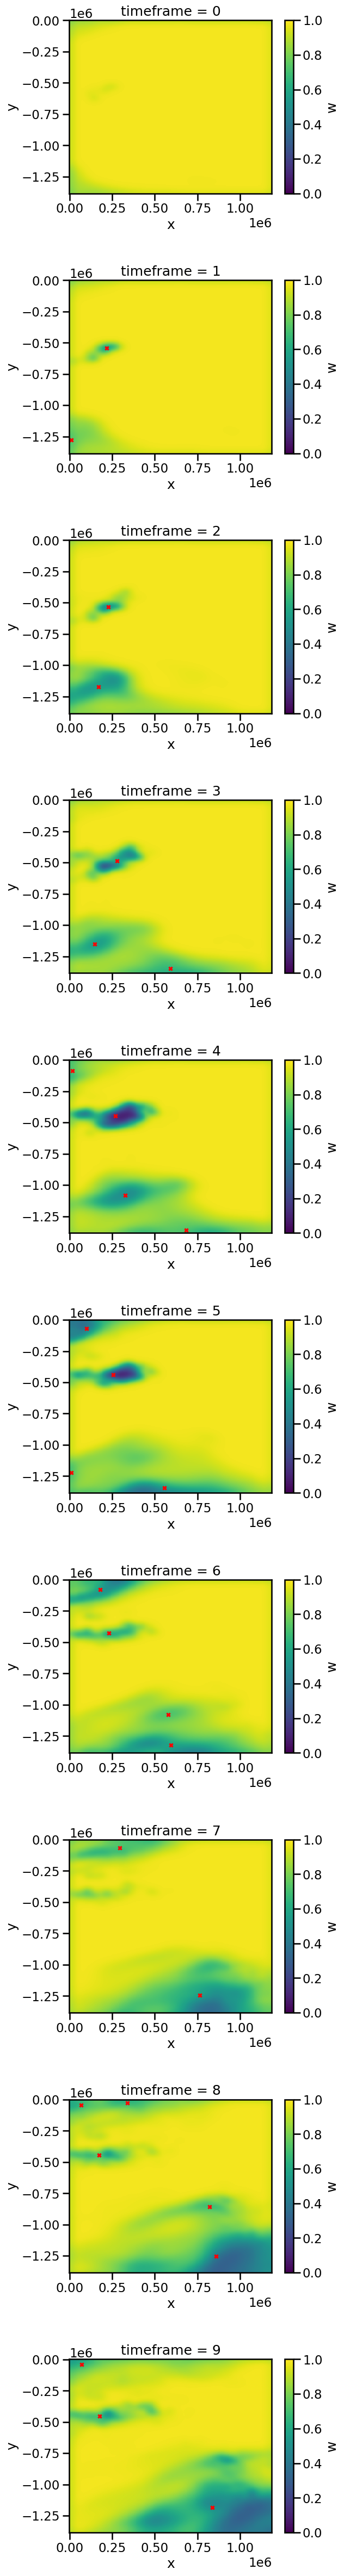

In [323]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import tobac

# === GLOBAL NORMALIZATION ===
vmin = float(test_data.min())
vmax = float(test_data.max())
test_data_norm = (test_data - vmin) / (vmax - vmin)

# === PARAMETERS ===
smooth = 8

# Convert original threshold (155) to normalized [0, 1] scale
norm_threshold = 0.75


# === FEATURE DETECTION ===
features = tobac.feature_detection_multithreshold(
    test_data_norm,
    threshold=[norm_threshold],  # single threshold in normalized space
    dxy=dxy,
    target="minimum",
    position_threshold="center",
    sigma_threshold=smooth
)

# === PLOTTING ===
fig, axs = plt.subplots(ncols=1, nrows=10, figsize=(6, 6*10), sharey=True)
plt.subplots_adjust(hspace=0.5)

for i, itime in enumerate(range(0, 10)):
    smoothed_frame = ndimage.gaussian_filter(test_data_norm.isel(time=itime).values, sigma=smooth)
    #smoothed_frame =test_data_norm.isel(time=itime).values
    temp_da = test_data_norm.isel(time=itime).copy()
    temp_da.data = smoothed_frame

    # consistent color range across all frames
    temp_da.plot(ax=axs[i], vmin=0, vmax=1, cmap="viridis")

    # overlay detections
    f = features[features["frame"] == itime]
    f.plot.scatter(
        x="x",
        y="y",
        s=20,
        ax=axs[i],
        color="red",
        marker="x",
    )

    axs[i].set_title(f"timeframe = {itime}")

plt.show()


## 3. Trajectory Linking

After we are done finding the features and associated segments for each frame it is necessary for further analysis to keep track of those elements troughout time. Linking is the tool for that. It connects the features of the timesteps which belong together. We are going to use the *linking_trackpy()* function here. The required inputs are the features, the two spacings and a maximum velocity of the features.

In [324]:

trajectories = tobac.linking_trackpy(features, test_data_norm, dt=3600, dxy=3000, v_max=50)

Frame 9: 3 trajectories present.


*fails without v_max*

Unsurprisingly, one trajectory was found. The returned object is another Dataset:

The new variable cell now indexes the features in the different time steps. Therefore we can use it to create a mask for our moving feature:

- and to show the track in our plots:

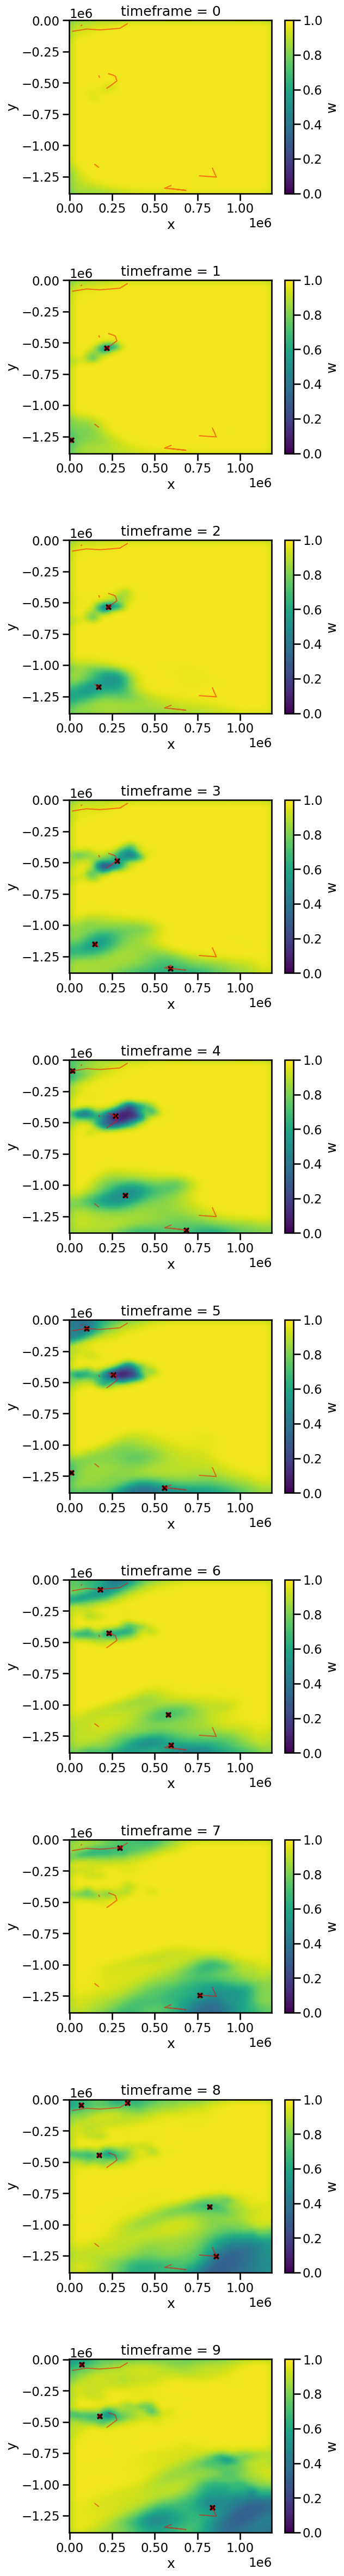

In [325]:
fig, axs = plt.subplots(ncols=1, nrows=10, figsize=(6, 6*10), sharey=True)
plt.subplots_adjust(hspace=0.5)
# fig.tight_layout()

cell_ids = trajectories["cell"].dropna().unique()

for i, itime in enumerate(range(0, 10)):
    # plot the 2D blob field in colors
    
    smoothed_frame = ndimage.gaussian_filter(test_data_norm.isel(time=itime).values, sigma=smooth)
    #smoothed_frame =test_data_norm.isel(time=itime).values
    
    temp_da = test_data_norm.isel(time=itime).copy()
    temp_da.data = smoothed_frame

    # consistent color range across all frames
    temp_da.plot(ax=axs[i], vmin=0, vmax=1, cmap="viridis")
    

    for cell_id in cell_ids:
        track = trajectories[trajectories["cell"] == cell_id]
        track_in_frame = track[track["frame"] == itime]

        # scatter current position
        axs[i].scatter(
            track_in_frame["x"],
            track_in_frame["y"],
            color="red",
            marker="o",
            s=30,
            alpha=0.8,
        )

        # draw a line between consecutive positions (sorted by time)
        axs[i].plot(
            track["x"],
            track["y"],
            color="red",
            linewidth=1.5,
            alpha=0.5,
        )

    # plot the detected feature as black cross
    f = features[features["frame"] == itime]
    f.plot.scatter(
        x="x",
        y="y",
        s=40,
        ax=axs[i],
        color="black",
        marker="x",
    )

    axs[i].set_title(f"timeframe = {itime}")

## 4. Segmentation

Another step after the feature detection and tracking is the segmentation of the data. This means we find the area surrounding our features belonging to the same cluster. Logically, we now need the already detected features as an additional input.



*Just a small thought here:* 

We often introduce the different steps as 1.feature detection, 2.segmentation and 3. tracking, so having the segmenation step actually before the trajectory linking. The order actually does not matter since the current segmentation approach is based on the feature detection output only and can be done before or after the linking.


*On further extensions:*

- Also, one could actually use the output of the segmentation (`segments` Dataset in the example below) as input for the tracking with the advantage that information on the area (ncells) is added in the dataframe. 

- One could also use the output of the tracking in the segmentation (`trajectories` Dataset from above) with the advantage that mask will contain only the features that are also linked to trajectories. 

These possibilities exist and could be utlized by you ...


In [326]:
segments_all = []

for itime in range(len(test_data.time)):
    print(f"Segmenting frame {itime} ...")
    print(f"Segmenting frame {itime}...")
    
    # --- SMOOTHING ---
    smoothed_frame = ndimage.gaussian_filter(
        test_data_norm.isel(time=itime).values, sigma=smooth
    )
    
    # Create a DataArray with the smoothed data but keep coordinates and attrs
    temp_da = test_data_norm.isel(time=[itime]).copy()
    temp_da.data = smoothed_frame[np.newaxis, ...]  # keep time dim
    
    field_2d = temp_da

    f = features[features["frame"] == itime]  # features in this frame
    
    if f.empty:
        print(f"No features found for frame {itime}, skipping segmentation.")
        segments_all.append((itime, None, None))
        continue

    # perform segmentation
    segment_labels, segments = tobac.segmentation_2D(
        f,
        field_2d,
        dxy=dxy,
        threshold=norm_threshold,
        target="minimum"
        
    )

    # store results
    segments_all.append((itime, segment_labels, segments))


Segmenting frame 0 ...
Segmenting frame 0...
No features found for frame 0, skipping segmentation.
Segmenting frame 1 ...
Segmenting frame 1...
Segmenting frame 2 ...
Segmenting frame 2...
Segmenting frame 3 ...
Segmenting frame 3...
Segmenting frame 4 ...
Segmenting frame 4...


/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: UserWarning: As of v1.6.0, segmentation with time length 1 will return time as a coordinate instead of dropping it (i.e., output will now be 1xMxN instead of MxN). 
  warnings.warn(
/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: UserWarning: As of v1.6.0, segmentation with time length 1 will return time as a coordinate instead of dropping it (i.e., output will now be 1xMxN instead of MxN). 
  warnings.warn(
/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: UserWarning: As of v1.6.0, segmentation with time length 1 will return time as a coordinate instead of dropping it (i.e., output will now be 1xMxN instead of MxN). 
  warnings.warn(
/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: Us

Segmenting frame 5 ...
Segmenting frame 5...
Segmenting frame 6 ...
Segmenting frame 6...
Segmenting frame 7 ...
Segmenting frame 7...
Segmenting frame 8 ...
Segmenting frame 8...
Segmenting frame 9 ...
Segmenting frame 9...


/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: UserWarning: As of v1.6.0, segmentation with time length 1 will return time as a coordinate instead of dropping it (i.e., output will now be 1xMxN instead of MxN). 
  warnings.warn(
/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: UserWarning: As of v1.6.0, segmentation with time length 1 will return time as a coordinate instead of dropping it (i.e., output will now be 1xMxN instead of MxN). 
  warnings.warn(
/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: UserWarning: As of v1.6.0, segmentation with time length 1 will return time as a coordinate instead of dropping it (i.e., output will now be 1xMxN instead of MxN). 
  warnings.warn(
/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: Us

As the name implies, the first object returned is an array in which the segmented areas belonging to each feature have the same label value as that feature. The second output is a dataframe of the detected features updated with information about their segmented regions (currently only the number of pixels segmented)

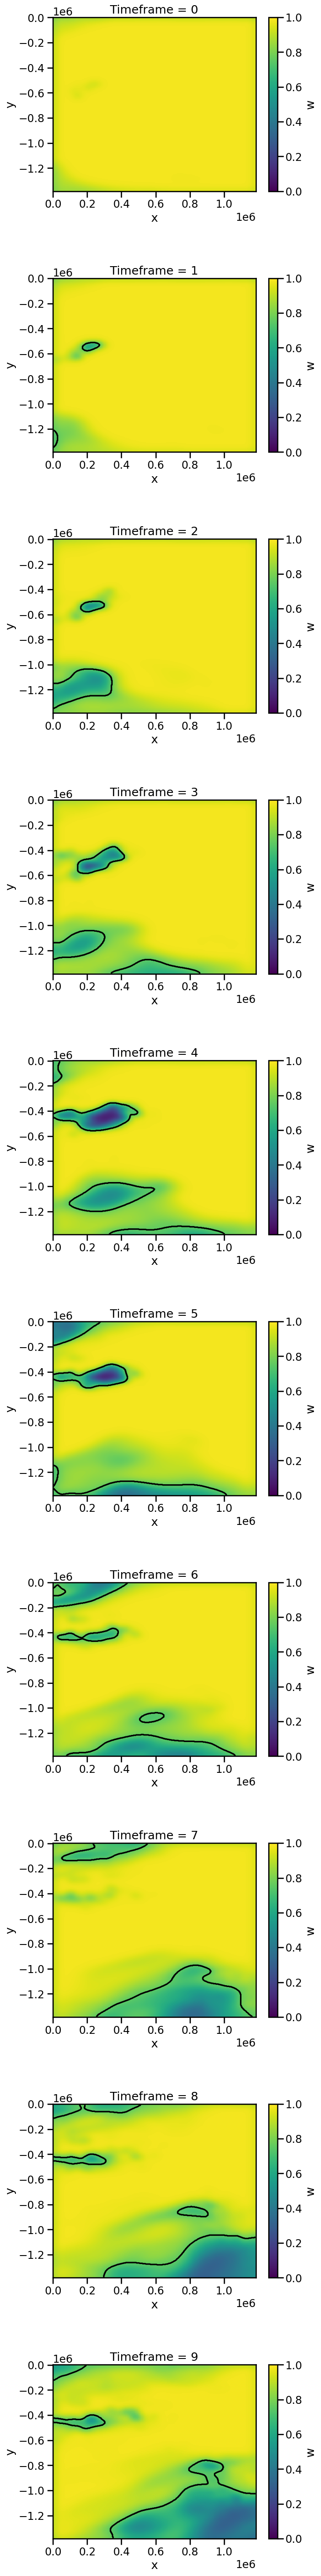

In [327]:
import matplotlib.pyplot as plt

# Select the frames you want to plot
plot_frames = range(0, 10)

fig, axs = plt.subplots(ncols=1, nrows=len(plot_frames), figsize=(7, 7*len(plot_frames)), sharey=True)
plt.subplots_adjust(hspace=0.5)

for i, itime in enumerate(plot_frames):
    # Get the field for this frame
    
    smoothed_frame = ndimage.gaussian_filter(test_data_norm.isel(time=itime).values, sigma=smooth)

    temp_da = test_data_norm.isel(time=itime).copy()
    temp_da.data = smoothed_frame

    # consistent color range across all frames
    temp_da.plot(ax=axs[i], vmin=0, vmax=1, cmap="viridis")
    
    # Extract segmentation for this frame from segments_all
    # We find the entry with matching time
    entry = next((s for s in segments_all if s[0] == itime), None)
    
    if entry is not None:
        
        _, seg_labels, _ = entry
        if seg_labels is not None:
            # seg_labels may have a single-element time dimension
            seg_labels2d = seg_labels.isel(time=0)  # drop the time dim for contour
            # Only plot contour if there are actual segmented pixels
            seg_labels2d.plot.contour(levels=[0.5], ax=axs[i], colors="k")
        

    axs[i].set_title(f"Timeframe = {itime}")
    
plt.show()


Since True/False corresponds to 1/0 in python, we can visualize the segments with a simple contour plot: